Life Expectancy Data Analysis


Analyze global life expectancy data and explore relationships between mortality, region, and health indicators.

1. Hypothesis Testing

In [ ]:
import numpy as np
from scipy import stats

# Data
data = [0.8411, 0.8191, 0.8182, 0.8125, 0.875, 0.858, 0.8532, 0.8483,
        0.8276, 0.7983, 0.8042, 0.873, 0.8282, 0.8359, 0.866]

mu0 = 0.82

# Perform t-test
t_stat, p_value = stats.ttest_1samp(data, mu0)

# Convert to one-tailed p-value
p_value = p_value / 2

print("t-value:", t_stat)
print("p-value:", p_value)

t-value: 2.718978782525142
p-value: 0.008313368681510822


the null hypothesis is
H0: mean <= 0.82
H1: mean > 0.82

t-value = 2.719
p-value = 0.0083

At 95% confidence:
0.0083 < 0.05
Reject the null hypothesis, there is sufficient evidence that the mean exceeds 0.82

At 99% confidence:
0.0083 < 0.01
Reject the null hypothesis,
there is sufficient evidence that the mean exceeds 0.82

2. Analysis of Life Expectancy

In [ ]:
import pandas as pd

url = "https://drive.google.com/uc?id=13HYWrB0Xn5HMy9pDZH-9iIh3ccwjhy9A"
df = pd.read_csv(url)

df.head()

,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,...,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
0,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.32,97,65,27.8,...,97,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5
1,Spain,European Union,2015,2.7,3.3,57.9025,10.35,97,94,26.0,...,97,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8
2,India,Asia,2007,51.5,67.9,201.0765,1.57,60,35,21.2,...,64,0.13,1076,1183.21,27.1,28.0,5.0,0,1,65.4
3,Guyana,South America,2006,32.8,40.5,222.1965,5.68,93,74,25.3,...,93,0.79,4146,0.75,5.7,5.5,7.9,0,1,67.0
4,Israel,Middle East,2012,3.4,4.3,57.9510,2.89,97,89,27.0,...,94,0.08,33995,7.91,1.2,1.1,12.8,1,0,81.7


In [ ]:
#2 (1)
print("Shape:", df.shape)
print(df.dtypes)
df.info()

Shape: (2866, 21)
Country                         object
Region                          object
Year                             int64
Infant_deaths                  float64
Under_five_deaths              float64
Adult_mortality                float64
Alcohol_consumption            float64
Hepatitis_B                      int64
Measles                          int64
BMI                            float64
Polio                            int64
Diphtheria                       int64
Incidents_HIV                  float64
GDP_per_capita                   int64
Population_mln                 float64
Thinness_ten_nineteen_years    float64
Thinness_five_nine_years       float64
Schooling                      float64
Economy_status_Developed         int64
Economy_status_Developing        int64
Life_expectancy                float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2866 entries, 0 to 2865
Data columns (total 21 columns):
 #   Column                       Non-Null

There are 2866 instances, 21 features, and the datatypes consist of integers for years, objects for country/region and float for things like life expectancy

In [ ]:
#2 (2)
df.describe()

,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
count,2866.000000,2866.000000,2866.000000,2866.000000,2866.000000,2866.000000,2866.000000,2866.000000,2866.000000,2866.000000,2866.000000,2866.000000,2866.000000,2866.000000,2866.000000,2866.000000,2866.000000,2866.000000,2866.000000
mean,2007.499302,30.346092,42.912666,192.206445,4.823742,84.297278,77.355548,25.033671,86.506281,86.277739,0.893699,11552.535590,36.651633,4.863922,4.897872,7.634508,0.207258,0.792742,68.861828
std,4.610577,27.536760,44.565055,114.900859,3.982410,15.991105,18.657590,2.193320,15.077211,15.530513,2.380663,16943.455946,136.441321,4.437399,4.524352,3.171734,0.405412,0.405412,9.405888
min,2000.000000,1.800000,2.300000,49.384000,0.000000,12.000000,10.000000,19.800000,8.000000,16.000000,0.010000,148.000000,0.080000,0.100000,0.100000,1.100000,0.000000,0.000000,39.400000
25%,2003.250000,8.100000,9.625000,106.881750,1.202500,78.000000,64.000000,23.200000,81.000000,81.000000,0.080000,1416.250000,2.092500,1.600000,1.600000,5.100000,0.000000,1.000000,62.700000
50%,2007.500000,19.550000,23.050000,163.841500,4.030000,89.000000,83.000000,25.500000,93.000000,93.000000,0.150000,4218.500000,7.830000,3.300000,3.350000,7.800000,0.000000,1.000000,71.400000
75%,2011.000000,47.275000,65.975000,246.665000,7.792500,96.000000,93.000000,26.400000,97.000000,97.000000,0.460000,12571.000000,23.672500,7.200000,7.300000,10.300000,0.000000,1.000000,75.400000
max,2015.000000,138.100000,224.900000,719.360500,17.870000,99.000000,99.000000,32.100000,99.000000,99.000000,21.680000,112418.000000,1379.860000,27.700000,28.600000,14.100000,1.000000,1.000000,83.800000


This shows the mean and standard deviation (std) of each feature of the dataset

In [ ]:
#2 (3)
df.groupby('Region')['Life_expectancy'].mean()


,Life_expectancy
Region,
Africa,57.847304
Asia,69.454861
Central America and Caribbean,72.437500
European Union,77.701386
Middle East,73.975446
North America,77.841667
Oceania,69.517614
Rest of Europe,74.558091
South America,72.780729


In [ ]:
#2 (4) drop duplicate rows
df = df.drop_duplicates()

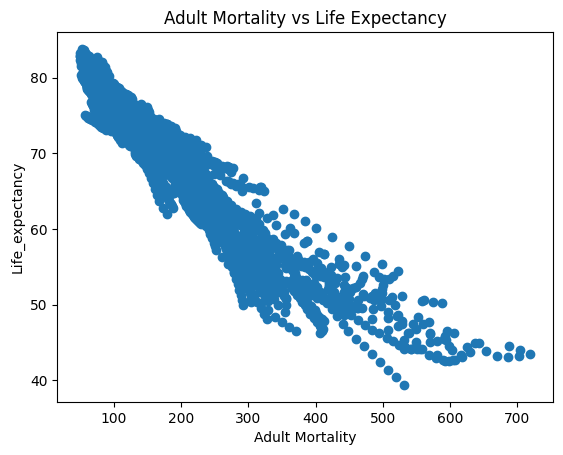

In [ ]:
#2 (5) create scatterplots for adult mortality to life expectancy

import matplotlib.pyplot as plt
plt.scatter(df['Adult_mortality'], df['Life_expectancy'])
plt.xlabel('Adult Mortality')
plt.ylabel('Life_expectancy')
plt.title('Adult Mortality vs Life Expectancy')
plt.show()

the scatterplot was created to visualize the relationship between adult mortality and life expectancy, it shows a negative relationship with higher adult mortality being associated with lower life expectancy

In [ ]:
#2 (6) determine dependent and independent variables
X = df.drop(['Country','Life_expectancy'], axis=1) #independent variables
y = df['Life_expectancy'] #dependent variable

print("Independent variables:", X.columns)
print("dependent varaible:", y.name)

Independent variables: Index(['Region', 'Year', 'Infant_deaths', 'Under_five_deaths',
       'Adult_mortality', 'Alcohol_consumption', 'Hepatitis_B', 'Measles',
       'BMI', 'Polio', 'Diphtheria', 'Incidents_HIV', 'GDP_per_capita',
       'Population_mln', 'Thinness_ten_nineteen_years',
       'Thinness_five_nine_years', 'Schooling', 'Economy_status_Developed',
       'Economy_status_Developing'],
      dtype='object')
dependent varaible: Life_expectancy


In [ ]:
#2 (7) split the data using conventional 80/20 split and use  a label encoder for Region
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

#drop unnecessary columns ( copy them from previous quesiton)

X = df.drop(['Country','Life_expectancy'], axis=1) #independent variables
y = df['Life_expectancy'] #dependent variable

#Encode Region
le = LabelEncoder()
X['Region'] = le.fit_transform(X['Region'])

#split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#standardize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 2291
Testing set size: 573


In [ ]:
#2 (8) build a machine learning model and display the results
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

#build model
model = LinearRegression()

#train model
model.fit(X_train, y_train)

#make predictions
y_pred = model.predict(X_test)

#evauluate using mean squared error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)


Mean Squared Error: 1.8417220845677011


 #2 (9) The mse of this model is 1.84, meaning the models performance for prediction error is relatively small compared to life expectancy values. One way to improve the model could be to use a different kind of regression because linear assumes a linear relationship and real life data is typically nonlinear.

3. Credit Card Application

In [ ]:
import pandas as pd

url = "https://drive.google.com/uc?id=1CFG1K6KkmjZ7A_b04isEp1hQ8MzoVYNj"
df2 = pd.read_csv(url)

df2.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,Class
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,1
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,1
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,1
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,1
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,1


In [ ]:
#3(2)
print("before:", df2.shape)
df2 = df2.dropna()
print( "after", df2.shape)

before: (690, 16)
after (653, 16)


In [ ]:
#3(3)perform feature encoding on categorical attributes
from sklearn.preprocessing import LabelEncoder

# Read data
url = "https://drive.google.com/uc?id=1CFG1K6KkmjZ7A_b04isEp1hQ8MzoVYNj"
df2 = pd.read_csv(url)

# Replace blanks with missing values, then drop missing rows
df2 = df2.replace(r'^\s*$', pd.NA, regex=True)
df2 = df2.dropna()

# Convert numeric columns to numeric type
numeric_cols = ['V2', 'V3', 'V8', 'V11', 'V14', 'V15', 'Class']
for col in numeric_cols:
    df2[col] = pd.to_numeric(df2[col], errors='coerce')

# Drop any rows that became missing after numeric conversion
df2 = df2.dropna()

# Categorical columns
categorical_cols = ['V1', 'V4', 'V5', 'V6', 'V7', 'V9', 'V10', 'V12', 'V13']

# Encode all categorical columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df2[col] = le.fit_transform(df2[col].astype(str))
    label_encoders[col] = le

# Final check
print(df2.head())
print(df2.info())

   V1     V2     V3  V4  V5  V6  V7    V8  V9  V10  V11  V12  V13    V14  V15  \
0   1  30.83  0.000   1   0  12   7  1.25   1    1    1    0    0  202.0    0   
1   0  58.67  4.460   1   0  10   3  3.04   1    1    6    0    0   43.0  560   
2   0  24.50  0.500   1   0  10   3  1.50   1    0    0    0    0  280.0  824   
3   1  27.83  1.540   1   0  12   7  3.75   1    1    5    1    0  100.0    3   
4   1  20.17  5.625   1   0  12   7  1.71   1    0    0    0    2  120.0    0   

   Class  
0      1  
1      1  
2      1  
3      1  
4      1  
<class 'pandas.core.frame.DataFrame'>
Index: 653 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      653 non-null    int64  
 1   V2      653 non-null    float64
 2   V3      653 non-null    float64
 3   V4      653 non-null    int64  
 4   V5      653 non-null    int64  
 5   V6      653 non-null    int64  
 6   V7      653 non-null    int64  
 7   V8      6

In [ ]:
#3(4) Dependent & independent variables

X = df2.drop('Class', axis=1) #independent variables (features)
y = df2['Class']  #dependent variable

print("independent variables:", X.columns)
print("dependent variable:", y.name)

independent variables: Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15'],
      dtype='object')
dependent variable: Class


In [ ]:
#3 (5) split the data 80/20 split (random_state = 42)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)
print("Training set:", X_train.shape)
print("Tesitng set:", X_test.shape)


Training set: (522, 15)
Tesitng set: (131, 15)


In [ ]:
#3 (6) build a tree based set ( decision tree )
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd

#build model
model = DecisionTreeClassifier(random_state=42)

#train model
model.fit(X_train, y_train)

#predictions
y_pred = model.predict(X_test)

#accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

#Feature Importance
importance = pd.Series(model.feature_importances_, index=X.columns)
print("\nFeature Importance:\n", importance.sort_values(ascending=False))

Accuracy: 0.7786259541984732
Confusion Matrix:
 [[60 16]
 [13 42]]

Feature Importance:
 V9     0.568690
V14    0.106381
V8     0.059291
V2     0.056995
V3     0.049413
V10    0.042192
V15    0.037320
V6     0.031418
V4     0.011049
V12    0.010571
V7     0.008418
V1     0.007708
V13    0.005139
V11    0.003854
V5     0.001560
dtype: float64


the decision tree classifiear was trained using the training dataset and the model achieved an accuracy of 0.779 (77.9%)

The confusion matrix shows that: 60 instances were correctly classified as class 0, 42 instances were correctly classified as class 1
16 instances were incorrectyl classified as class 1
and 13 instances were incorrectly classified as class 0


Feature importance analysis shows that V9 is the most influential feature (0.57) followed by V14, V8, and V2. Features with higher importance values have a greater impact on predicting the class.

overall, the model performs reasonably well with good accuracy and identifies key features that influence classification.

